In [1]:
from thermolib.thermodynamics.fep import BaseFreeEnergyProfile, SimpleFreeEnergyProfile, plot_profiles
from thermolib.thermodynamics.histogram import Histogram1D
from thermolib.tools import read_wham_input, decorrelate, plot_histograms_overlap_1d, plot_histograms_1d
from thermolib.thermodynamics.trajectory import ColVarReader
from thermolib.units import *

import numpy as np
import matplotlib.pyplot as plt


In [2]:
from thermolib.thermodynamics.fep import SimpleFreeEnergyProfile, plot_profiles
from thermolib.thermodynamics.histogram import Histogram1D, plot_histograms
from thermolib.tools import read_wham_input, blav, decorrelate, corrtime_from_acf
from thermolib.thermodynamics.trajectory import ColVarReader
from thermolib.units import *

import numpy as np, matplotlib.pyplot as pp

In [3]:
import re
from glob import glob
import os

In [4]:
import re
from glob import glob
import os

def atoi(text):
    return int(text) if text.isdigit() else text

def natural_keys(text):
    return [atoi(c) for c in re.split(r'(\d+)', text)]

def simple_braceexpand(pattern):
    match = re.search(r'\{(\d+)\.\.(\d+)\}', pattern)
    if not match:
        return [pattern]
    
    start, end = map(int, match.groups())
    
    return [
        pattern[:match.start()] + str(i) + pattern[match.end():]
        for i in range(start, end + 1)
    ]

def braceexpand_glob(filename: str) -> list:
    file_list = []
    
    for pattern in simple_braceexpand(filename):
        file_list.extend(glob(pattern))
    
    return sorted(file_list, key=natural_keys)
def extract_variables(file_path):
    kappa = None
    at = None
    with open(file_path, 'r') as f:
        for line in f:
            if 'KAPPA=' in line:
                kappa_match = re.search(r'KAPPA=([\d.]+)', line)
                if kappa_match:
                    kappa = kappa_match.group(1)
            if 'AT=' in line:
                at_match = re.search(r'AT=([+-]?[\d.]+)', line)
                if at_match:
                    at = at_match.group(1)
    return kappa, at

In [11]:
def plot_umbrellas(fn):
    fig, ax = plt.subplots(1)  # of gewoon plt.subplots()

    files = sorted(glob(fn), key=natural_keys)
    for file in files:
        cv = np.loadtxt(file)
        ax.hist(cv[::4, 1], bins=np.arange(-40, 40, 0.2),
                density=True, alpha=0.3, color="grey")

    ax.set_xlabel("Z (Å)")
    ax.set_ylabel("Probability")
    ax.set_ylim((0, 1))
    ax.set_xlim((-40, 40))

    plt.show()

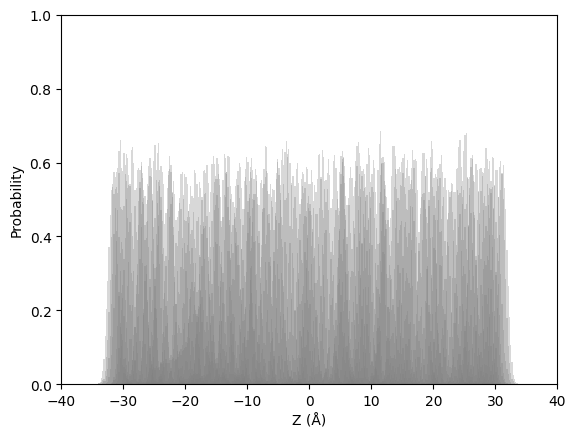

In [12]:
plot_umbrellas("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/umbrella_unbiased/plumed_*-colvar_5.dat")

In [5]:
import os

os.chdir("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/umbrella_unbiased")
fn_meta = "wham_input5.txt"

colvar_reader = ColVarReader([1], units=['au'], verbose=True)

temp, biasses, trajectories = read_wham_input(
    fn_meta,
    colvar_reader,
    '%s',
    bias_potential='Parabola1D',
    q01_unit='au',
    kappa1_unit='kjmol',
    verbose=True
)

Temperature set at 310.000000
Read 5000001 trajectory samples for 1 CVs from plumed_1-colvar_5.dat
Added bias Parabola1D (plumed_1-colvar_5.dat): K=5 kjmol  q0=-3.199e+01 au
Read 4996763 trajectory samples for 1 CVs from plumed_2-colvar_5.dat
Added bias Parabola1D (plumed_2-colvar_5.dat): K=5 kjmol  q0=-3.152e+01 au
Read 5000001 trajectory samples for 1 CVs from plumed_3-colvar_5.dat
Added bias Parabola1D (plumed_3-colvar_5.dat): K=5 kjmol  q0=-3.108e+01 au
Read 5000001 trajectory samples for 1 CVs from plumed_4-colvar_5.dat
Added bias Parabola1D (plumed_4-colvar_5.dat): K=5 kjmol  q0=-3.044e+01 au
Read 5000001 trajectory samples for 1 CVs from plumed_5-colvar_5.dat
Added bias Parabola1D (plumed_5-colvar_5.dat): K=5 kjmol  q0=-3.005e+01 au
Read 5000001 trajectory samples for 1 CVs from plumed_6-colvar_5.dat
Added bias Parabola1D (plumed_6-colvar_5.dat): K=5 kjmol  q0=-2.950e+01 au
Read 5000001 trajectory samples for 1 CVs from plumed_7-colvar_5.dat
Added bias Parabola1D (plumed_7-colva

<Figure size 640x480 with 0 Axes>

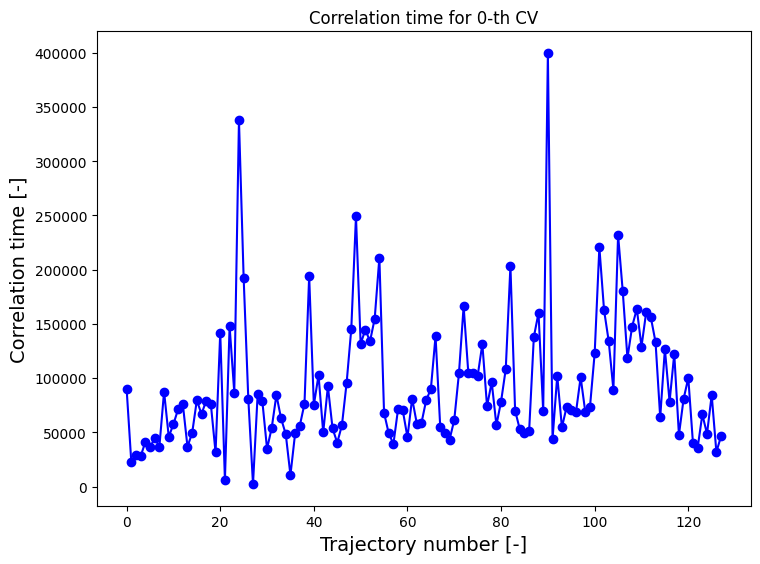

In [7]:
corrtimes = decorrelate(trajectories, plot = True, n_nested_envelopes=0)

<Figure size 640x480 with 0 Axes>

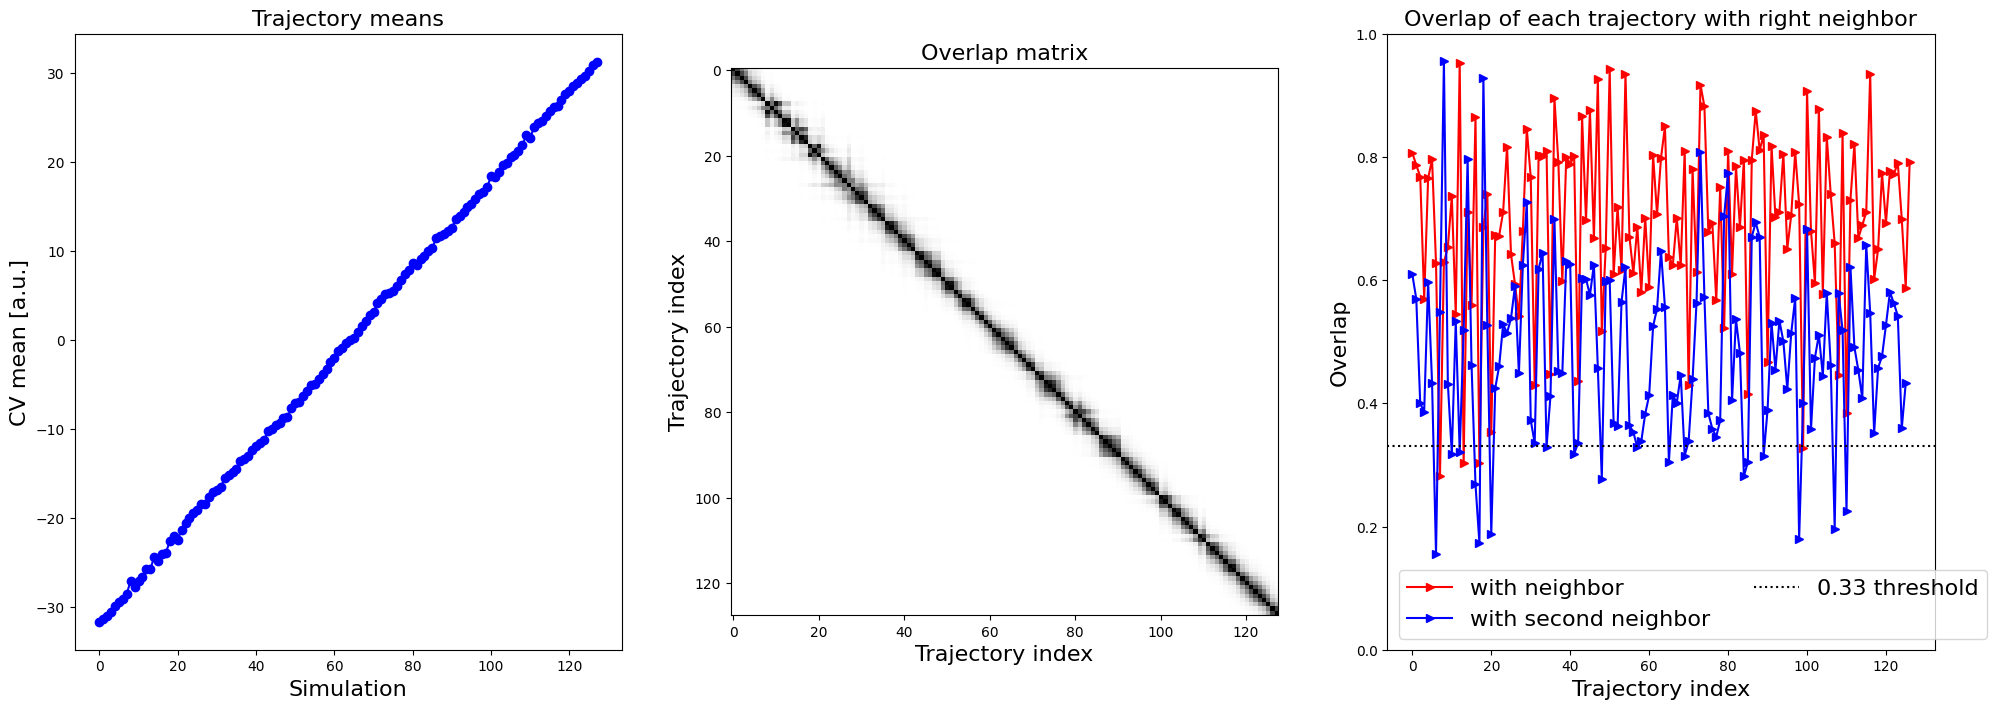

In [8]:
plot_histograms_overlap_1d(trajectories)

In [9]:
bins = np.arange(-33, 33, 0.2)
hist = Histogram1D.from_wham(bins, 
                             trajectories, 
                             biasses, 
                             temp, 
                             Nscf=30000, ### next params needed to control optimization stringency for convergence
                             convergence=1e-6, 
                             verbosity='medium', 
                             bias_subgrid_num=50, 
                             bias_thress=1e-4,
                            error_estimate = "mle_f_cov",
                            corrtimes= corrtimes)

Initialization ...
Constructing individual histograms for each biased simulation ...
Computing bias on grid ...
Solving WHAM equations (SCF loop) ...
SCF Converged!
Estimating error ...
  defining zero-mask ...
    deactivated 0 bins
    deactivated 0 sims
  applying zero-mask ...
  inverting Fisher matrix ...
---------------------------------------------------------------------
TIMING SUMMARY
  initializing: 00h 00m 00.000s
  histograms  : 00h 00m 05.065s
  bias poten. : 00h 00m 00.050s
  solve scf   : 00h 00m 01.147s
  error est.  : 00h 00m 00.095s
  TOTAL       : 00h 00m 06.359s
---------------------------------------------------------------------


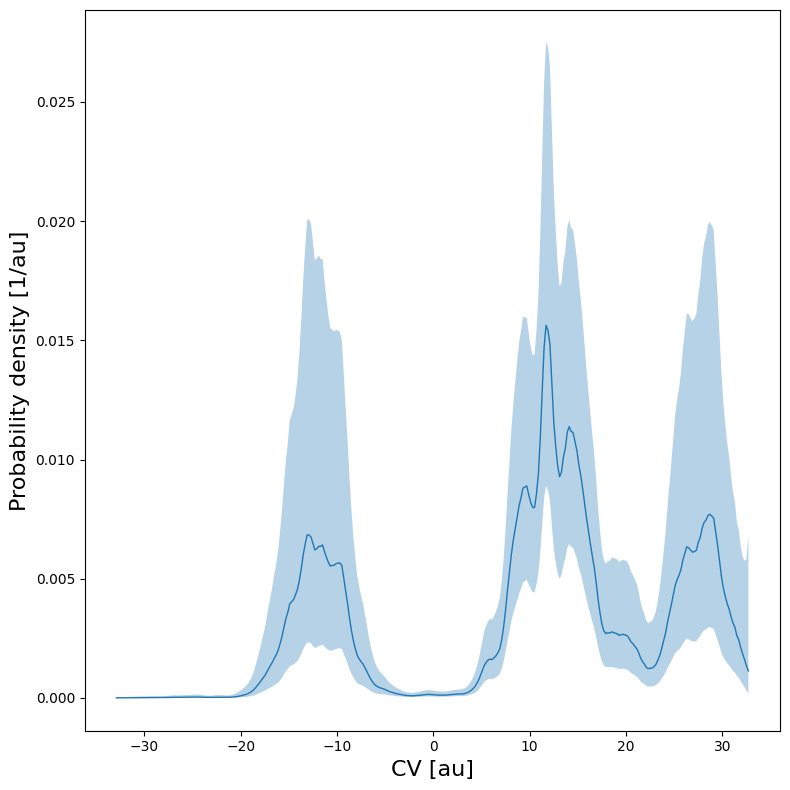

In [10]:
hist.plot()

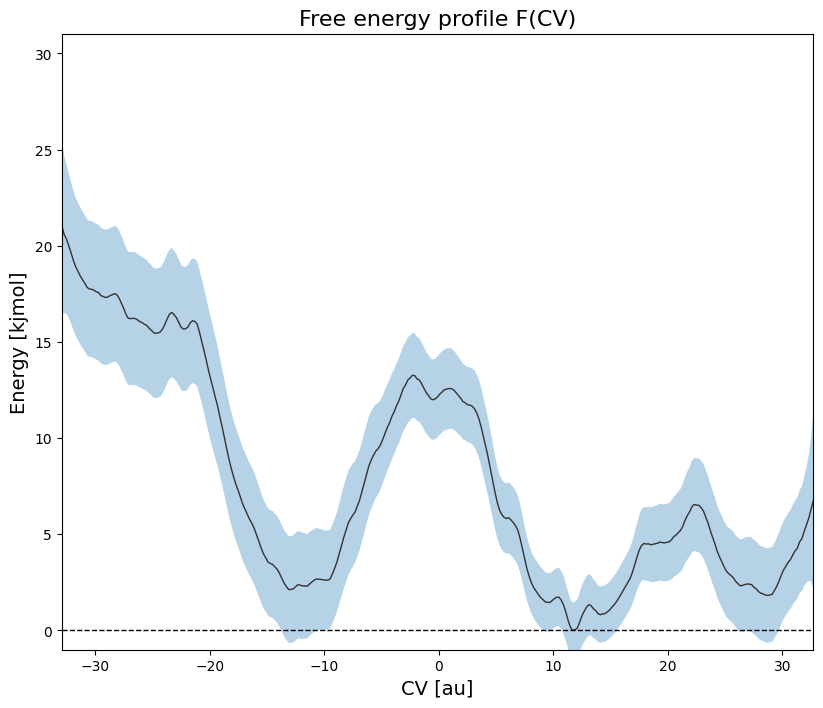

In [11]:
fep = SimpleFreeEnergyProfile.from_histogram(
    hist,
    temp,
    cv_output_unit='au',
    cv_label='CV',
    f_output_unit='kjmol'
)
fep.set_ref(ref='min')

# plotten
fep.plot()

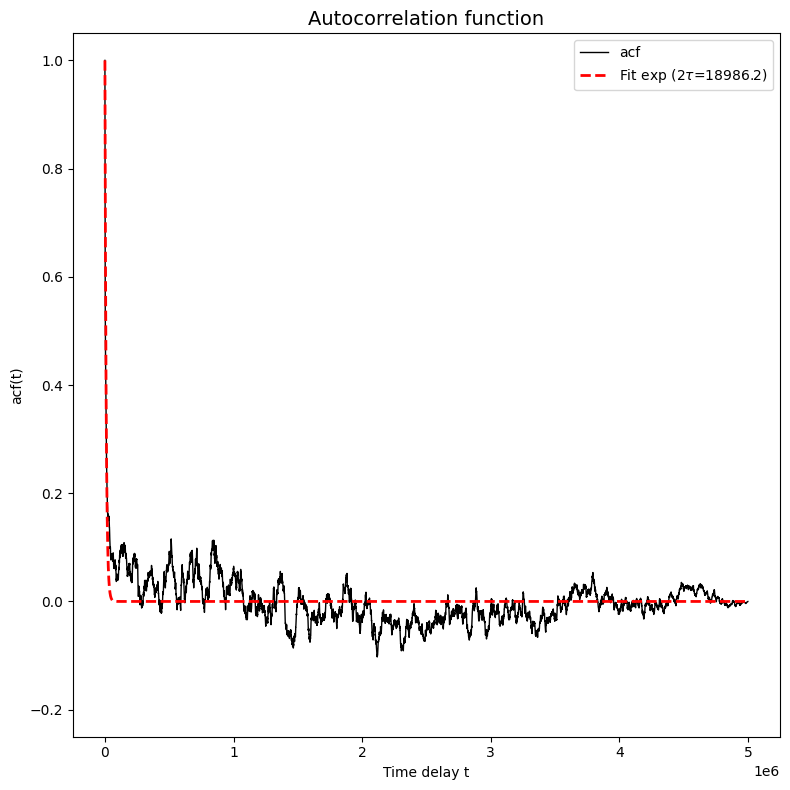

In [22]:
corrtime = corrtime_from_acf(trajectories[9], plot=True, n_nested_envelopes=0, p0=1000)

In [14]:
from thermolib.thermodynamics.state import Minimum, Maximum, Integrate
from thermolib.constants import boltzmann

#Define a local maximum located somewhere in the cv range [-0.5,0.5]:
ts = Maximum('TransState', cv_range=[-10,10])

#Define a local minima in the cv range [-inf, 0]
r = Minimum('MicroReac', cv_range=[10, 20])
r2= Minimum('MicroReac_left', cv_range= [-20, -10])
#Define a macrostate as a collection (integration) of all microstates in a given cv_range=[left, right] where left/right can either be a Microstate (such as the above defined ts) or a float specifying the cv value. Let's consider the example of a reactant state defined a going from -inf to the transition state. As the integration is done over the corresponding boltzmann probabilities, we also need to definethe value of beta (=1/kT):
beta = 1.0/(boltzmann*300*kelvin)
R = Integrate('MacroReac', [-30, ts], beta)

#Compute the value of the states for the previously construced FEP:
for state in [ts, R, r, r2]:
    state.compute(fep)

In [18]:
#you can access the cv or f value by calling the get_cv() or get_f() routine:
for state in [ts, R, r, r2]:
    cv = state.get_cv()
    F = state.get_F()
    print('%s:    cv = %.3f au     f  = %.3f kjmol' %(state.name, cv, F/kjmol))

TransState:    cv = -1.492 au     f  = 14.051 kjmol
MacroReac:    cv = -11.974 au     f  = -2.848 kjmol
MicroReac:    cv = 12.032 au     f  = -0.496 kjmol
MicroReac_left:    cv = -12.176 au     f  = 1.044 kjmol


In [19]:
#you can also print the print thermodynamic state properties more easily by calling its print routine:
lower, upper = r.F_dist.nsigma_conf_int(2)
error = (upper-lower)/2.0
error /= parse_unit("kjmol")

for state in [ts, r, r2, R]:
    state.print()

MICROSTATE TransState:
--------------
  index =  None
  F     = 14.051 +- 2.186 kjmol
  CV    = -1.492 +- 2.955 au

MICROSTATE MicroReac:
--------------
  index =  None
  F     = -0.496 +- 1.287 kjmol
  CV    = 12.032 +- 1.517 au

MICROSTATE MicroReac_left:
--------------
  index =  None
  F     = 1.044 +- 2.248 kjmol
  CV    = -12.176 +- 1.563 au

MACROSTATE MacroReac:
--------------
  F       = -2.848 +- 2.200 kjmol
  CV Mean = -11.974 +- 0.591 au
  CV StD  = 2.880 +- 0.287 au



In [29]:
fep = SimpleFreeEnergyProfile.from_base(fep)

In [20]:
fep.process_states(lims=[-30,-10,10,30], verbose=True)

MICROSTATE ts:
--------------
  index =  None
  F     = 13.686 +- 1.915 kjmol
  CV    = -1.252 +- 3.273 au

MICROSTATE r:
--------------
  index =  None
  F     = 1.342 +- 2.450 kjmol
  CV    = -12.036 +- 1.908 au

MICROSTATE p:
--------------
  index =  None
  F     = -0.588 +- 1.022 kjmol
  CV    = 12.264 +- 4.748 au

MACROSTATE R:
--------------
  F       = -3.064 +- 2.234 kjmol
  CV Mean = -12.004 +- 0.655 au
  CV StD  = 2.968 +- 0.294 au

MACROSTATE P:
--------------
  F       = -5.884 +- 0.574 kjmol
  CV Mean = 16.217 +- 2.641 au
  CV StD  = 6.788 +- 1.220 au



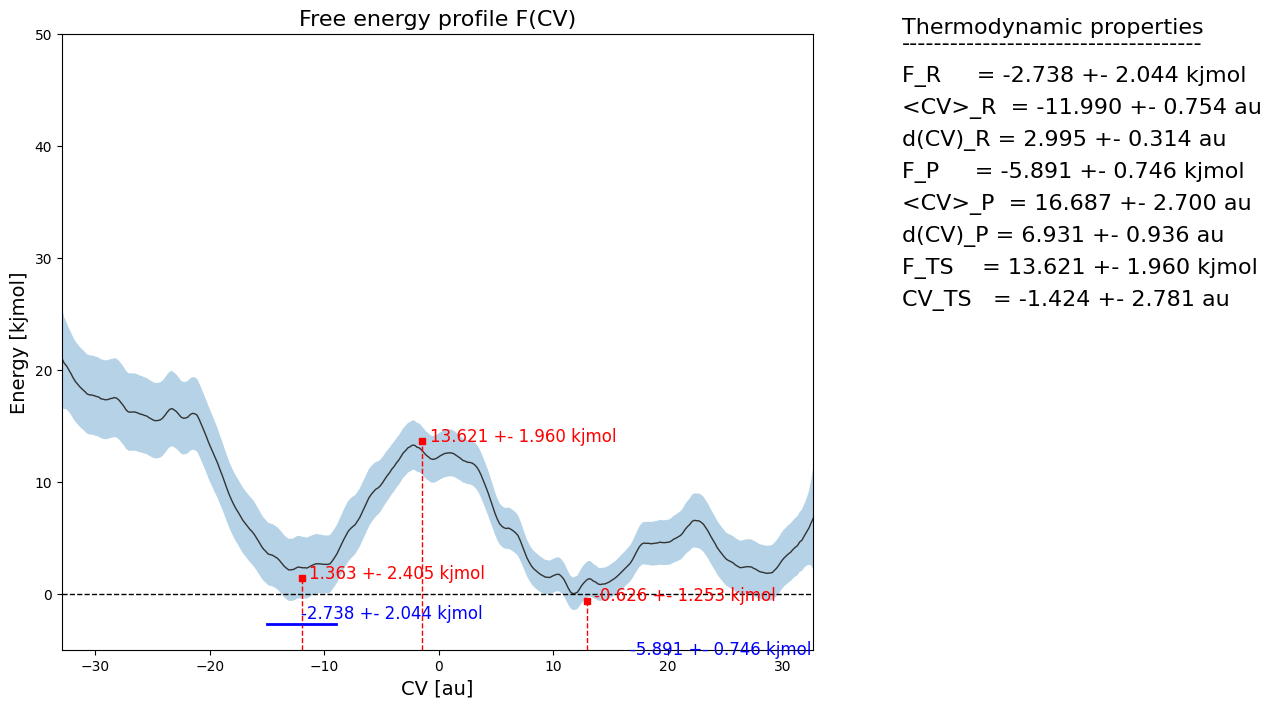

In [21]:
fep.set_ref(ref='min')
fep.plot(flims=[-5,50])

In [12]:
from thermolib.error import *

def calc_dF(state_1, state_2):
    """
    Takes in two Macrostate objects and calculates the
    free energy difference $\Delta F$ with correct error
    propagation. 
    
    Returns a GaussianDistribution object.
    """
    dF = Propagator(ncycles=10000, verbose=False)
    dF.gen_args_samples(state_1.F_dist, state_2.F_dist)
    dF.calc_fun_values(lambda x, y: y-x)
    err = dF.get_distribution(target_distribution=GaussianDistribution)
    return err

def process_permeation_profile(fep):
    ts_left = Maximum(name = "ts_left", 
                  cv_range = [-25, -20], 
                  cv_unit = fep.cv_output_unit, 
                  f_unit = fep.f_output_unit)
    ts_left.compute(fep)
    ts_mid = Maximum(name = "ts_mid", 
                  cv_range = [-10, 10], 
                  cv_unit = fep.cv_output_unit, 
                  f_unit = fep.f_output_unit)
    ts_mid.compute(fep)

    ts_right = Maximum(name = "ts_right", 
                  cv_range = [20, 30], 
                  cv_unit = fep.cv_output_unit, 
                  f_unit = fep.f_output_unit)
    ts_right.compute(fep)
    
    transition_states = [ts_left, ts_mid, ts_right]
    for t in transition_states: t.print()
    
    S1 = Integrate("S1", cv_range=[-30, -20], 
               beta = fep.beta,
               cv_unit=fep.cv_output_unit,
               f_unit = fep.f_output_unit)
    S1.compute(fep)

    S2 = Integrate("S2", cv_range=[-20, ts_mid], 
               beta = fep.beta,
               cv_unit=fep.cv_output_unit,
               f_unit = fep.f_output_unit)
    S2.compute(fep)

    S3 = Integrate("S3", cv_range=[ts_mid, ts_right], 
               beta = fep.beta,
               cv_unit=fep.cv_output_unit,
               f_unit = fep.f_output_unit)
    S3.compute(fep)

    S4 = Integrate("S4", cv_range=[ts_right, 32], 
               beta = fep.beta,
               cv_unit=fep.cv_output_unit,
               f_unit = fep.f_output_unit)
    S4.compute(fep)
    macrostates = [S1, S2, S3, S4]
    for m in macrostates: m.print()

    for i in range(len(macrostates)-1):
        dF = calc_dF(macrostates[i], macrostates[i+1])
        print(f"dF (S{i+1}-S{i+2})={dF.print(unit='kjmol')}")
    return transition_states, macrostates

<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_3371615/2426546141.py:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  free energy difference $\Delta F$ with correct error


In [15]:
fep_committed_ts, fep_committed_macrostates = process_permeation_profile(fep)

MICROSTATE ts_left:
--------------
  index =  None
  F     = 16.847 +- 3.416 kjmol
  CV    = -22.808 +- 1.889 au

MICROSTATE ts_mid:
--------------
  index =  None
  F     = 14.050 +- 1.796 kjmol
  CV    = -1.592 +- 2.451 au

MICROSTATE ts_right:
--------------
  index =  None
  F     = 7.643 +- 2.146 kjmol
  CV    = 22.368 +- 0.807 au

MACROSTATE S1:
--------------
  F       = 10.139 +- 2.920 kjmol
  CV Mean = -24.195 +- 0.612 au
  CV StD  = 2.743 +- 0.155 au

MACROSTATE S2:
--------------
  F       = -2.833 +- 2.334 kjmol
  CV Mean = -11.904 +- 0.748 au
  CV StD  = 2.782 +- 0.283 au

MACROSTATE S3:
--------------
  F       = -5.015 +- 0.798 kjmol
  CV Mean = 12.772 +- 1.089 au
  CV StD  = 3.755 +- 0.434 au

MACROSTATE S4:
--------------
  F       = -2.730 +- 2.055 kjmol
  CV Mean = 27.635 +- 0.356 au
  CV StD  = 2.179 +- 0.209 au

dF (S1-S2)=-12.969 +- 3.726 kjmol
dF (S2-S3)=-2.177 +- 2.466 kjmol
dF (S3-S4)=2.287 +- 2.208 kjmol


In [16]:
print("Activation energy S1-ts1")
calc_dF(fep_committed_macrostates[0], fep_committed_ts[0]).print(unit = "kjmol")

Activation energy S1-ts1


'6.744 +- 4.497 kjmol'

In [17]:
print("Activation energy S4-ts3")
calc_dF(fep_committed_macrostates[-1], fep_committed_ts[-1]).print(unit = "kjmol")

Activation energy S4-ts3


'10.363 +- 2.944 kjmol'

In [18]:
print("Activation energy S2-ts2")
calc_dF(fep_committed_macrostates[1], fep_committed_ts[1]).print(unit = "kjmol")

Activation energy S2-ts2


'16.878 +- 2.929 kjmol'

In [28]:
print("Activation energy S3-ts2")
calc_dF(fep_committed_macrostates[2], fep_committed_ts[1]).print(unit = "kjmol")

Activation energy S3-ts2


'19.049 +- 2.339 kjmol'

In [37]:
from thermolib.error import *
from thermolib.units import *
from thermolib.constants import *
T = 310
mass = (0.555516/avogadro)*kilogram # molar mass is 346 g/mol
beta = 1/(boltzmann*310)

A =  np.sqrt((boltzmann*310)/(2*np.pi*mass))
print("Prefactor: A=", round(A, 5))

beta = fep.beta

def fun_k(x, y):
    return A*np.exp(-beta*x)/y

def fun_F(x, y):
    f = -np.log(planck*fun_k(x,y)/(boltzmann*T))*boltzmann*T
    return f

calc_barrier = Propagator(ncycles = 5000, verbose = False)
k_fwd = calc_barrier(fun_k, fep_committed_ts[1].F_dist, fep_committed_macrostates[1].Z_dist, target_distribution=LogGaussianDistribution)
k_fwd.print(unit = "1e7/second")

Prefactor: A= 1e-05


'21.511 <= 99.739 <= 299.719 1e7/second'

In [38]:
f_fwd = calc_barrier(fun_F, fep_committed_ts[1].F_dist, fep_committed_macrostates[1].Z_dist, target_distribution=GaussianDistribution)
f_fwd.print(unit = "kjmol")

'23.216 +- 3.345 kjmol'

In [39]:
k_bckwd = calc_barrier(fun_k, fep_committed_ts[1].F_dist, fep_committed_macrostates[2].Z_dist, target_distribution=LogGaussianDistribution)
k_bckwd.print(unit = "1e7/second")

'12.668 <= 35.198 <= 79.259 1e7/second'

In [40]:
f_bckwd = calc_barrier(fun_F, fep_committed_ts[1].F_dist, fep_committed_macrostates[2].Z_dist, target_distribution=GaussianDistribution)
f_bckwd.print(unit = "kjmol")

'25.564 +- 2.371 kjmol'